<a href="https://colab.research.google.com/github/DinoKiller0607/My_Pytorch_Notes/blob/main/02_pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification
Classification is a problem of predicting whether something is one thing or the other (there can be multiple things as the option, though).
Book version of the notebook – https://www.learnpytorch.io/02_pytorch_classification/

All other resources – https://github.com/DinoKiller0607/pytorch-deep-learning

In case you get stuck, refer – https://github.com/mrdbourke/pytorch-deep-learning/discussions

## Making classification data ready

In [1]:
from sklearn.datasets import make_circles
import numpy as np
from torch.nn import CrossEntropyLoss

# Make aa 1000 samples
n_samples = 1000
# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)
len(X), len(y)

(1000, 1000)

In [2]:
# Print the data
print(f"First 5 samples of X are :\n{X[:5]}")
print(f"First 5 samples of y are :\n{y[:5]}")

First 5 samples of X are :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y are :
[1 1 1 1 0]


In [3]:
# Make a Dataframe of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

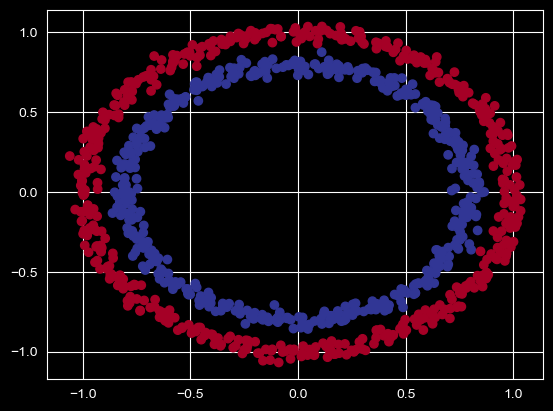

In [5]:
# Visualize, Visualize, Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu
            );

**Note:** The data we are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### Check input and output shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### Turn data into tensors and create train and test splits

In [9]:
import torch
torch.__version__

'2.12.0+cu130'

In [10]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [11]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [12]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [13]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2, # 0.2 = 20% of data will be test set
                                                    random_state = 42)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

## Building a model
Let's build a model to classify the blue and red points.
To do so, we want to:
1. Set up device-agnostic code, so our code will run on accelerator (GPU) if there is one.
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [14]:
# PyTorch and nn
import torch
from torch import nn
# Make device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've set up device-agnostic code, let's create a model that:
1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`
2. Creates 2 `nn.Linear()` layers that are capable of handling the shapes of our data.
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model.
4. Instantiate an instance of our model class and send it to our target `device`

In [15]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer1= nn.Linear(in_features= 2, out_features= 8) # Takes in 2 features and upscales to 8
        self.layer2= nn.Linear(in_features= 8, out_features= 1) # Takes in 8 features and downscales to 1
    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer2(self.layer1(x))  # x -> layer1 -> layer2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

**Note**: The number of input features of the current layer MUST MATCH the number of output features of previous layer.
Otherwise, it will throw shape mismatch errors.

In [16]:
device

'cuda'

In [17]:
next(model_0.parameters()).device

device(type='cuda', index=0)

Let's replicate the model above using `nn.Sequential()`

In [18]:
model_0_new = nn.Sequential(
    nn.Linear(in_features = 2, out_features= 8),
    nn.Linear(in_features = 8, out_features= 1)
).to(device)
model_0_new, next(model_0_new.parameters()).device

(Sequential(
   (0): Linear(in_features=2, out_features=8, bias=True)
   (1): Linear(in_features=8, out_features=1, bias=True)
 ),
 device(type='cuda', index=0))

`nn.Sequential()` is an easier way to create neural networks. However, if you want full control over the architecture, subclassing `nn.Module()` is a better way.

In [19]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5500,  0.6445],
                      [-0.6889, -0.4700],
                      [ 0.6097,  0.4217],
                      [ 0.3698, -0.6478],
                      [-0.6094, -0.0933],
                      [ 0.5895, -0.6906],
                      [ 0.5262,  0.0889],
                      [-0.2464, -0.3152]], device='cuda:0')),
             ('layer1.bias',
              tensor([ 0.2612,  0.1490, -0.6954,  0.4186,  0.6901, -0.4990,  0.6001, -0.5879],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2864,  0.1976,  0.1842, -0.2284,  0.0472,  0.2913,  0.1012,  0.0774]],
                     device='cuda:0')),
             ('layer2.bias', tensor([-0.1995], device='cuda:0'))])

In [20]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of untrained predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of untrained predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.4356],
        [-0.3205],
        [-0.6059],
        [-0.3879],
        [-0.3971],
        [-0.3285],
        [-0.1698],
        [-0.1711],
        [-0.6144],
        [-0.3105]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [21]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### Set up loss function and optimizer
Which loss function or optimizer should you use?
Again... this is problem-specific.
For example, for a regression problem you might want MAE or MSE (mean absolute error or mean squared error).
For a classification problem, you might want binary cross-entropy or categorical cross-entropy (or simply, cross-entropy).
As a reminder, the loss function measures how wrong your predictions are.
And for optimizers, two of the most common and useful are — SGD, and Adam optimizer.
However, there are several built-in options in PyTorch.
* For some common choices of loss functions and optimizers — https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-function-and-optimizer
* For the loss function we're going to use `torch.nn.BCEWithLogitsLoss()`, for more on what binary cross entropy (BCE) is, check out this article — https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a
* For a definition on what a logit is in deep learning — https://stackoverflow.com/a/52111173/7900723
* For different optimizers see `torch.optim`.

In [22]:
# Set up a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = BCE with sigmoid activation built-in
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr= 0.1)
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5500,  0.6445],
                      [-0.6889, -0.4700],
                      [ 0.6097,  0.4217],
                      [ 0.3698, -0.6478],
                      [-0.6094, -0.0933],
                      [ 0.5895, -0.6906],
                      [ 0.5262,  0.0889],
                      [-0.2464, -0.3152]], device='cuda:0')),
             ('layer1.bias',
              tensor([ 0.2612,  0.1490, -0.6954,  0.4186,  0.6901, -0.4990,  0.6001, -0.5879],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2864,  0.1976,  0.1842, -0.2284,  0.0472,  0.2913,  0.1012,  0.0774]],
                     device='cuda:0')),
             ('layer2.bias', tensor([-0.1995], device='cuda:0'))])

In [23]:
# Calculate accuracy — out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

## Train Model
To train the model, we're going to need to build a training loop:
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss Backward (Backpropagation)
5. Optimizer step (Gradient Descent)
### Going from raw logits -> prediction probabilities -> prediction labels
Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabiities to **prediction labels** by either rounding them or taking the argmax.

In [24]:
# View the first 5 outputs of the forward pass on the test data. These are the Raw Logits
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.4356],
        [-0.3205],
        [-0.6059],
        [-0.3879],
        [-0.3971]], device='cuda:0')

In [25]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities.
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3928],
        [0.4206],
        [0.3530],
        [0.4042],
        [0.4020]], device='cuda:0')

In [26]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5, `y=0` (class 0)




In [27]:
# Find the predicted labels
y_pred_labels = torch.round(y_pred_probs)
# In full (logits -> pred probs -> pred labels)
y_pred_labels2 = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
# Check equality
print(torch.eq(y_pred_labels.squeeze(), y_pred_labels2.squeeze()))
# Get rid of the extra dimension
y_pred_labels.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [28]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Building a training and testing loop


In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Set the number of epochs
epochs = 100
# Put the data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# Build training and evaluation loop
for epoch in range(epochs):
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # 2. Calculate the loss / accuracy
  # Simple BCE Loss
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                y_train) # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits,  ## nn.BCEWithLogitsLoss expects raw logits as input
                 y_train) # it is more numerically stable to pass y_logits rather than sigmoid(logits), ref docs.
  acc = accuracy_fn(y_true= y_train,
                  y_pred= y_pred)
  # 3. Optimizer zero grad
  optimizer.zero_grad()
  # 4. Loss backward (backpropagation)
  loss.backward()
  # 5. Optimizer step
  optimizer.step()
  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate the loss/accuracy
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= test_pred)
  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.71679, Acc: 50.00% | Test loss:  0.71748, Test acc: 50.00%
Epoch: 10 | Loss: 0.69724, Acc: 46.75% | Test loss:  0.70036, Test acc: 41.00%
Epoch: 20 | Loss: 0.69386, Acc: 47.12% | Test loss:  0.69694, Test acc: 47.50%
Epoch: 30 | Loss: 0.69323, Acc: 49.62% | Test loss:  0.69598, Test acc: 47.50%
Epoch: 40 | Loss: 0.69308, Acc: 50.50% | Test loss:  0.69555, Test acc: 46.50%
Epoch: 50 | Loss: 0.69303, Acc: 50.88% | Test loss:  0.69529, Test acc: 46.00%
Epoch: 60 | Loss: 0.69301, Acc: 50.75% | Test loss:  0.69511, Test acc: 46.00%
Epoch: 70 | Loss: 0.69300, Acc: 51.00% | Test loss:  0.69499, Test acc: 45.50%
Epoch: 80 | Loss: 0.69299, Acc: 51.38% | Test loss:  0.69490, Test acc: 46.50%
Epoch: 90 | Loss: 0.69299, Acc: 51.38% | Test loss:  0.69483, Test acc: 47.00%


In [30]:
device

'cuda'

### Make predictions and evaluate the model
From the metrics it looks like that our model isn't learning anything. Why?
In order to investigate this, we shall write a function to plot/visualize the decision boundaries.
In other words, **Visualize, visualize, visualize!**

In [31]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

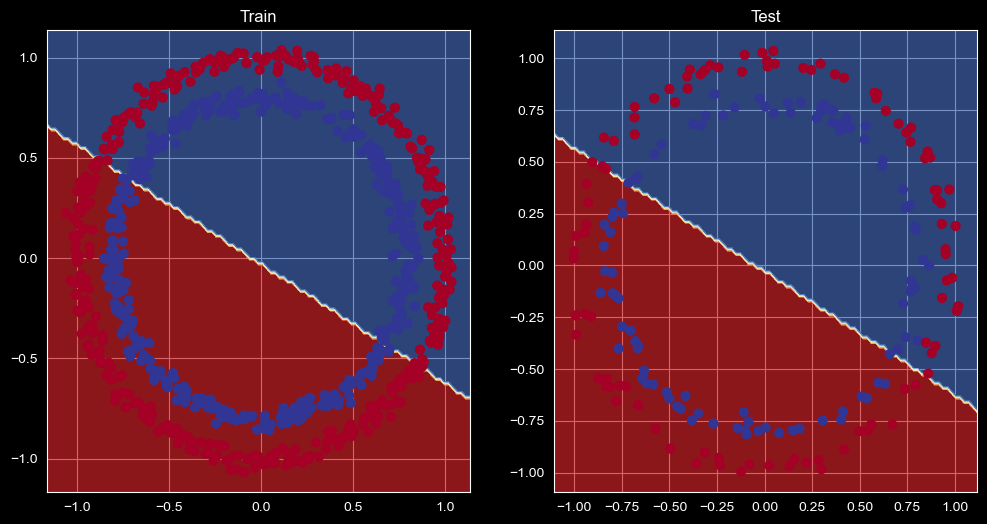

In [32]:
# Plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [33]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5350,  0.6409],
                      [-0.7008, -0.4728],
                      [ 0.6040,  0.4203],
                      [ 0.3802, -0.6453],
                      [-0.6156, -0.0947],
                      [ 0.5770, -0.6936],
                      [ 0.5191,  0.0872],
                      [-0.2484, -0.3157]])),
             ('layer1.bias',
              tensor([ 0.2945,  0.1738, -0.6797,  0.3948,  0.7008, -0.4694,  0.6145, -0.5821])),
             ('layer2.weight',
              tensor([[ 0.2820,  0.2577,  0.0693, -0.1934,  0.1593,  0.2145,  0.1423,  0.0274]])),
             ('layer2.bias', tensor([-0.0853]))])

## Improving a model (from a model perspective)
How to do it?
* Add more data.
* Add more layers - give the model more layers to learn about patterns in the data.
* Add more hidden units - go from 5 hidden units to 10 hidden units.
* Fit for longer. Give the model more epochs to learn better.
* Change the activation function.
* Change the learning rate.
* Change the loss function.

These options are all from the model's perspective because they deal directly with the model rather than the data.
And, because these options are all values, we as machine learning engineers and data scientists, we can refer to as **hyperparameters**.

Let's try and improve our model by:
* Adding more hidden units: 5 -> 10
* Increase the number of layers 2-> 3
* Increase the number of epochs:

In [34]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [35]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
  def forward(self, x):
    # Alternate way
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    # return z
    return self.layer_3(self.layer_2(self.layer_1(x)))  # This is a faster way tho
model_1 = CircleModelV1().to(device)
model_1, next(model_1.parameters()).device

(CircleModelV1(
   (layer_1): Linear(in_features=2, out_features=10, bias=True)
   (layer_2): Linear(in_features=10, out_features=10, bias=True)
   (layer_3): Linear(in_features=10, out_features=1, bias=True)
 ),
 device(type='cuda', index=0))

In [36]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5350,  0.6409],
                      [-0.7008, -0.4728],
                      [ 0.6040,  0.4203],
                      [ 0.3802, -0.6453],
                      [-0.6156, -0.0947],
                      [ 0.5770, -0.6936],
                      [ 0.5191,  0.0872],
                      [-0.2484, -0.3157]])),
             ('layer1.bias',
              tensor([ 0.2945,  0.1738, -0.6797,  0.3948,  0.7008, -0.4694,  0.6145, -0.5821])),
             ('layer2.weight',
              tensor([[ 0.2820,  0.2577,  0.0693, -0.1934,  0.1593,  0.2145,  0.1423,  0.0274]])),
             ('layer2.bias', tensor([-0.0853]))])

In [37]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [38]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()
# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [39]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Train for longer
epochs = 1000
# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
  ### Training
  model_1.train()
  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))   # logits -> prediction probs -> labels
  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
  # 3. Optimizer zero grad
  optimizer.zero_grad()
  # 4. Loss backward (Backpropagation)
  loss.backward()
  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate the loss
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch}/{epochs} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.4f} | Test acc: {test_acc:.2f}")

Epoch: 0/1000 | Train Loss: 0.6940 | Train Acc: 50.88 | Test Loss: 0.6926 | Test acc: 51.00
Epoch: 100/1000 | Train Loss: 0.6930 | Train Acc: 50.38 | Test Loss: 0.6938 | Test acc: 48.00
Epoch: 200/1000 | Train Loss: 0.6930 | Train Acc: 51.12 | Test Loss: 0.6944 | Test acc: 46.00
Epoch: 300/1000 | Train Loss: 0.6930 | Train Acc: 51.62 | Test Loss: 0.6946 | Test acc: 45.00
Epoch: 400/1000 | Train Loss: 0.6930 | Train Acc: 51.12 | Test Loss: 0.6946 | Test acc: 46.00
Epoch: 500/1000 | Train Loss: 0.6930 | Train Acc: 51.00 | Test Loss: 0.6947 | Test acc: 46.00
Epoch: 600/1000 | Train Loss: 0.6930 | Train Acc: 51.00 | Test Loss: 0.6947 | Test acc: 46.00
Epoch: 700/1000 | Train Loss: 0.6930 | Train Acc: 51.00 | Test Loss: 0.6947 | Test acc: 46.00
Epoch: 800/1000 | Train Loss: 0.6930 | Train Acc: 51.00 | Test Loss: 0.6947 | Test acc: 46.00
Epoch: 900/1000 | Train Loss: 0.6930 | Train Acc: 51.00 | Test Loss: 0.6947 | Test acc: 46.00


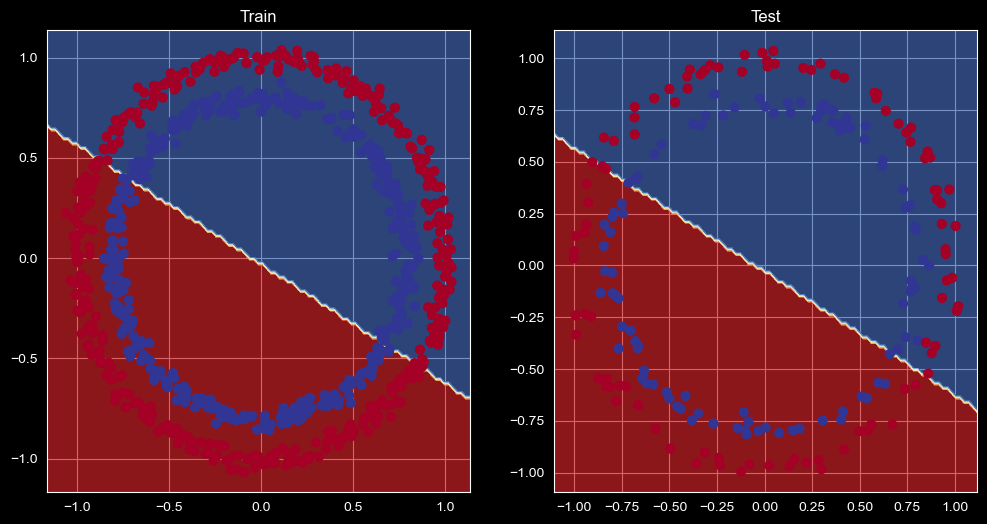

In [40]:
# Plot the decision boundary
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

### Preparing data to see if our model can fit a straight line
One way to troubleshoot a bigger problem to see if it can solve a smaller problem.

In [41]:
# Create some data (same as notebook 1)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01
# Create the data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias
# Check the data
X_regression[:5], y_regression[:5], len(X_regression)

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]),
 100)

In [42]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]
# Check the lengths of each
len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

In [43]:
def plot_predictions(train_data= X_train_regression,
                     train_labels= y_train_regression,
                     test_data= X_test_regression,
                     test_labels= y_test_regression,
                     predictions=None):
    """
    Plots linear training data and test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

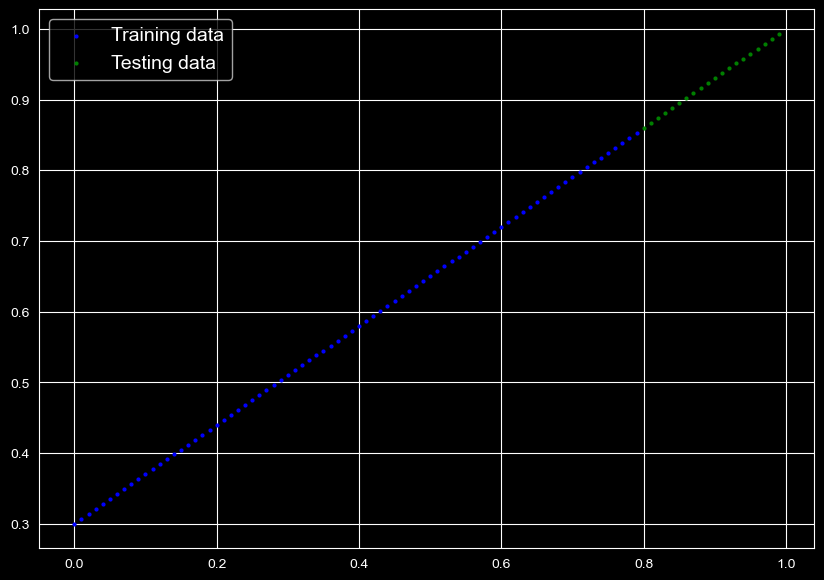

In [44]:
plot_predictions()

In [45]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### Adjusting `model_1` to fit a straight line

In [46]:
# Same architecture as model_1 but using nn.Sequential()
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [47]:
# Loss and Optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.001)

In [48]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test loss: 0.94965
Epoch: 100 | Loss: 0.40272 | Test loss: 0.54029
Epoch: 200 | Loss: 0.05876 | Test loss: 0.13480
Epoch: 300 | Loss: 0.01461 | Test loss: 0.03342
Epoch: 400 | Loss: 0.00308 | Test loss: 0.00008
Epoch: 500 | Loss: 0.00309 | Test loss: 0.00012
Epoch: 600 | Loss: 0.00309 | Test loss: 0.00018
Epoch: 700 | Loss: 0.00299 | Test loss: 0.00011
Epoch: 800 | Loss: 0.00299 | Test loss: 0.00016
Epoch: 900 | Loss: 0.00289 | Test loss: 0.00011


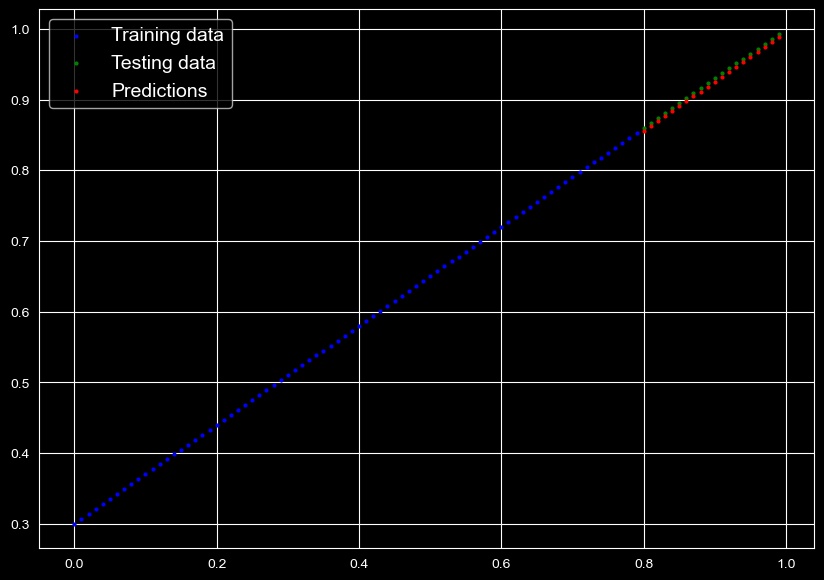

In [49]:
# Turn on evaluation mode
model_2.eval()
with torch.inference_mode():
    # Calculate the predictions
    y_preds = model_2(X_test_regression)
# Plot the predictions
plot_predictions(predictions=y_preds.cpu())

## The missing piece: Non_Linearity
"What patterns could you draw if you were given an infinite number of linear and nonlinear lines?"
Or in machine learning terms, an infinite (but really is infinite) number of linear and non-linear functions?

### Recreating non-linear data (red and blue circles)

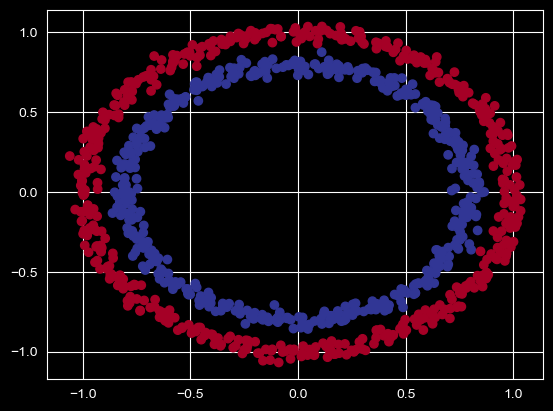

In [50]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap= plt.cm.RdYlBu);

In [51]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### Building a model with non-linearity
* Linearity – straight lines
* Non-linearity – curved lines

In [52]:
# Build a model with non-linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        # Where should we add our non-linear activation functions?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [53]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.01)

### Training a model with non-linearity

In [54]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put the data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Set the number of epochs
epochs = 30000

for epoch in range(epochs):
    # Training
    model_3.train()
    y_logits = model_3(X_train).squeeze()   # raw logits
    y_pred = torch.round(torch.sigmoid(y_logits))   # logits -> prediction probs -> pred labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true= y_train,
                      y_pred= y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true= y_test,
                               y_pred= test_pred)
    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Acc: 50.00% | Test loss:  0.69325, Test acc: 50.00%
Epoch: 100 | Loss: 0.69248, Acc: 50.38% | Test loss:  0.69264, Test acc: 50.00%
Epoch: 200 | Loss: 0.69225, Acc: 59.00% | Test loss:  0.69233, Test acc: 56.00%
Epoch: 300 | Loss: 0.69209, Acc: 70.12% | Test loss:  0.69214, Test acc: 67.00%
Epoch: 400 | Loss: 0.69195, Acc: 68.38% | Test loss:  0.69197, Test acc: 70.00%
Epoch: 500 | Loss: 0.69181, Acc: 58.50% | Test loss:  0.69179, Test acc: 62.00%
Epoch: 600 | Loss: 0.69168, Acc: 54.00% | Test loss:  0.69163, Test acc: 56.00%
Epoch: 700 | Loss: 0.69155, Acc: 53.25% | Test loss:  0.69148, Test acc: 53.00%
Epoch: 800 | Loss: 0.69141, Acc: 52.62% | Test loss:  0.69133, Test acc: 53.00%
Epoch: 900 | Loss: 0.69128, Acc: 52.75% | Test loss:  0.69118, Test acc: 53.00%
Epoch: 1000 | Loss: 0.69115, Acc: 53.00% | Test loss:  0.69104, Test acc: 52.50%
Epoch: 1100 | Loss: 0.69103, Acc: 52.88% | Test loss:  0.69089, Test acc: 53.00%
Epoch: 1200 | Loss: 0.69090, Acc: 53.12%

In [55]:
# Evaluate the model
model_3.eval()
with torch.inference_mode():
    y_test_preds = torch.round(torch.sigmoid(model_3(X_test).squeeze()))
    test_loss = loss_fn(model_3(X_test).squeeze(), y_test)
    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= y_test_preds)
print(f"Test loss: {test_loss: .5f} | Test acc: {test_acc:.2f}%")

Test loss:  0.03363 | Test acc: 100.00%


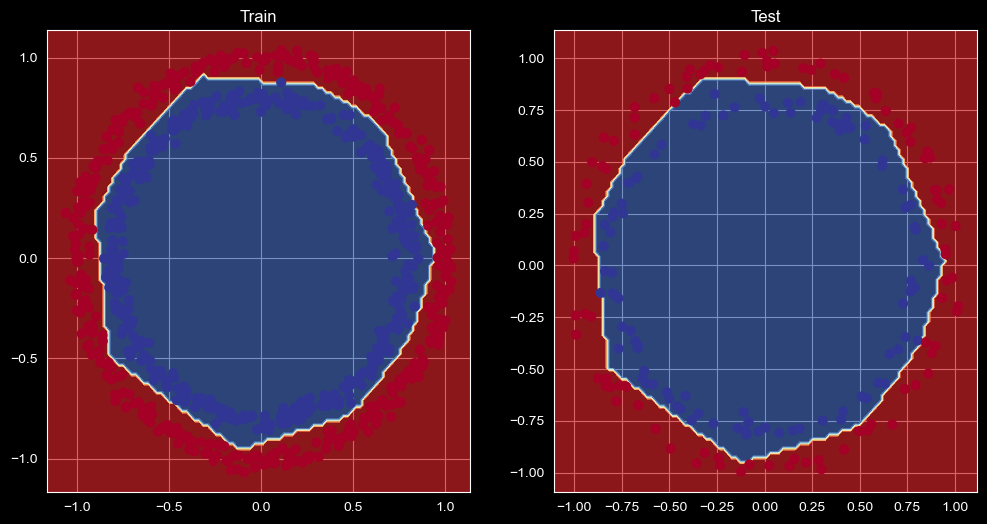

In [60]:
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

**Challenge**: Can you improve the above model by pushing the test accuracy?

Actually, we can! The model has drastically increased its performance by decreasing the learning rate and increasing the number of epochs.
## Replicating non-linear activation functions
Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data, and it tries to figure out the patterns on its own.
And these tools are linear and non-linear functions.

In [61]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A.dtype

torch.float32

In [62]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

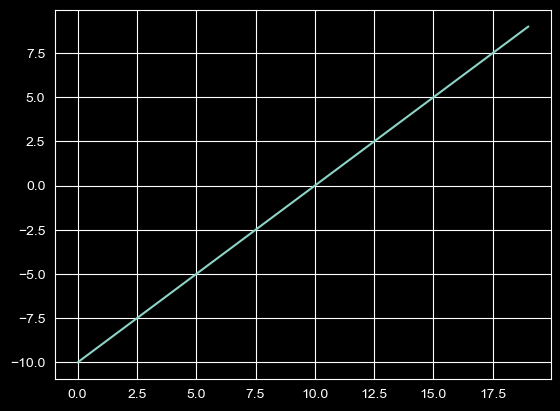

In [63]:
# Visualize the tensor
plt.plot(A)

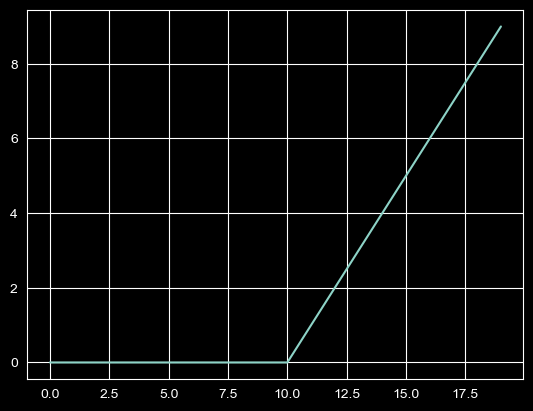

In [68]:
plt.plot(torch.relu(A));

In [69]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.max(x, torch.zeros_like(x))
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

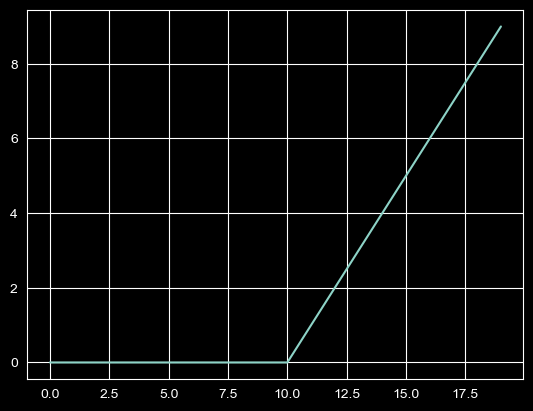

In [70]:
# Plot ReLU activation function
plt.plot(relu(A));

In [71]:
# Now let's plot sigmoid function
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

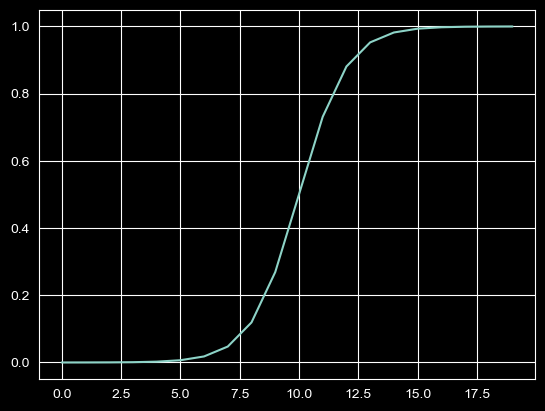

In [72]:
plt.plot(sigmoid(A));

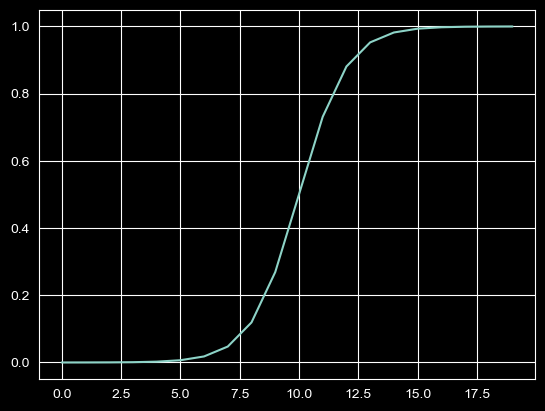

In [73]:
plt.plot(torch.sigmoid(A));

## Putting it all together with a multiclass classification problem
* Binary classification = one thing or another (cat vs dog, sushi vs pizza, etc.)
* Multiclass classification = differentiating between multiple entities (cat vs dog vs car vs dinosaur)
### Creating a toy multi-class dataset

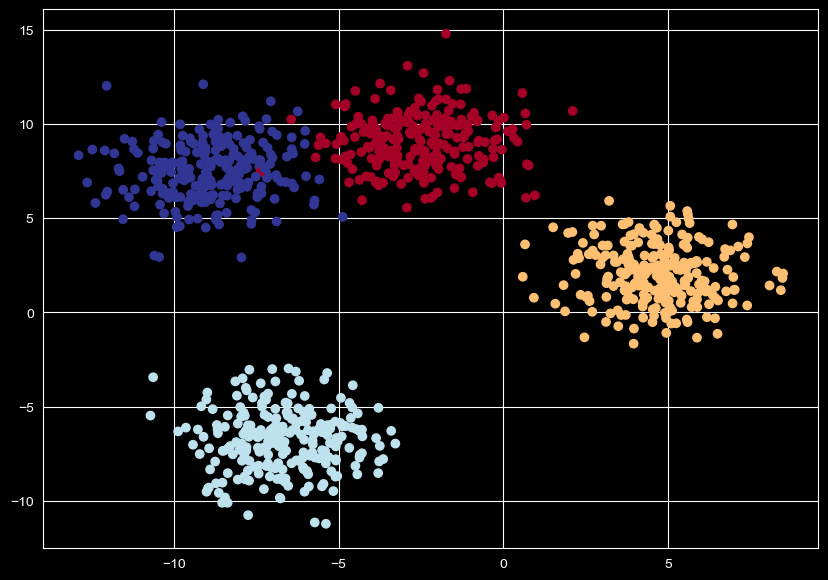

In [77]:
# Import dependencies
import numpy as np
import torch
from sklearn.datasets import make_blobs
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html
from sklearn.model_selection import train_test_split
# Set the hyperparameters
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_STATE = 42
# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples= 1000,
                            n_features= NUM_FEATURES,
                            centers= NUM_CLASSES,
                            cluster_std= 1.5,    # Give the clusters more space between them
                            random_state= RANDOM_STATE)
# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.float32)
# 3. Split into test and train sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size= 0.2,
                                                                        random_state= RANDOM_STATE)
# 4. Plot data - visualize, visualize, visualize
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

### Building a multi-class classification model in PyTorch

In [78]:
# Create device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [83]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units= 8):
        """
        Initializes the multi-class classification model.
        Args:
            input_features (int): The number of input features to the model.
            output_features (int): The number of output features from the model.
            hidden_units (int): The number of hidden units in the model, default 8.
        Returns:

        Example:

        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)
# Create an instance of a blobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_4, device

(BlobModel(
   (linear_layer_stack): Sequential(
     (0): Linear(in_features=2, out_features=8, bias=True)
     (1): ReLU()
     (2): Linear(in_features=8, out_features=8, bias=True)
     (3): ReLU()
     (4): Linear(in_features=8, out_features=4, bias=True)
   )
 ),
 'cuda')

In [81]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

In [82]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

### Create a loss function and an optimizer for a multi-class classification model

In [84]:
# Set up a loss function for multi-class classification - loss function measures how wrong our predictions are...
loss_fn = nn.CrossEntropyLoss()
# Set up an optimizer for multi-class classification - optimizer updates our model parameters to try and reduce the loss
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr= 0.01)   # learning rate is a hyperparameter that you can change